# Predicción de popularidad de canciones en Spotify

**Autor:** Gino Andrades,Verónica Cereceda

**Fecha de Creación:** Septiembre de 2026

**Versión:** 1.0

## Descripción

Desarrollo de un análisis exploratorio de datos (EDA) y diagnóstico de calidad sobre el dataset de canciones de Spotify, aplicando las etapas iniciales de la metodología CRISP-DM, con el fin de identificar los patrones, calidad y variables relevantes que describen la popularidad musical.

## Información general

Realizar un análisis exploratorio de los datos, incluyendo preparación, transformación y diagnóstico de calidad, aplicando la metodología CRISP-DM, con el fin de identificar patrones, calidad de los datos y variables relevantes asociadas al nivel de popularidad de las canciones.

## **1. Configuración del Entorno**

Se prepara el entorno de trabajo,se descarga el dataset desde el repositorio de GitHub del proyecto, se importan las librerías necesarias para el análisis y se carga el archivo CSV en un Data para su exploración.

### *1.1 Descarga del Dataset*

In [1]:
!wget https://raw.githubusercontent.com/VeritoCR/Repositorio_Spotify_Tracks/refs/heads/main/data/Spotify_Tracks_Dataset.csv

--2026-09-06 19:51:07--  https://raw.githubusercontent.com/VeritoCR/Repositorio_Spotify_Tracks/refs/heads/main/data/Spotify_Tracks_Dataset.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20118244 (19M) [text/plain]
Saving to: ‘Spotify_Tracks_Dataset.csv.46’

Spotify_Tracks_Data 100%[===================>]  19.19M  38.3MB/s    in 0.5s    

2026-09-06 19:51:12 (38.3 MB/s) - ‘Spotify_Tracks_Dataset.csv.46’ saved [20118244/20118244]



### *1.2 Importaciones necesarias para trabajar.*

In [2]:
!pip install wordcloud==1.9.6


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn import set_config
from wordcloud import WordCloud

In [4]:
set_config(transform_output="pandas")

### *1.3 Cargar los registros a la variable "data" con pandas*

Se carga el dataset **Spotify_Tracks_Dataset.csv** directamente desde el repositorio de GitHub del proyecto, y se realiza una primera inspección general para conocer su tamaño, tipos de datos y estructura antes de iniciar el diagnóstico de calidad.

In [5]:
data=pd.read_csv('Spotify_Tracks_Dataset.csv')

### *1.4 Definicion de la Variable Objetivo*


In [6]:
target = 'popularity' 

## **2. Exploración Inicial y Perfilamiento**

Se realiza un análisis exploratorio completo del dataset, revisando su estructura, calidad de datos, distribución de variables y las relaciones entre variables,con foco en identificar qué factores se asocian con la variable objetivo. Esta etapa permite detectar problemas de calidad que deberán tratarse en la preparación de datos, así como hallazgos relevantes sobre el comportamiento del catálogo musical.

### *2.1 Inspección Estructural del Dataset*


In [7]:
# Dimensiones del dataset
print(f"Filas: {data.shape[0]}, Columnas: {data.shape[1]}")

Filas: 114000, Columnas: 21


In [8]:
# Tipos de datos por columna
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

El dataset contiene 114.000 registros y 21 columnas. Se observan tres tipos de datos principales:
- **Variables categóricas**:track_id,artists,album_name, track_name,track_genre.
- **Variables numéricas**:popularity,duration_ms,danceability,energy, loudness, tempo,entre otras.
- **Variable booleana**:explicit.

Además, se identifica la columna **Unnamed:0**,que corresponde a un índice residual sin valor analítico.

Atributos Metadatos e Identificación

    Unnamed: 0 (Índice persistido): Índice numérico proveniente de la exportación del archivo CSV. No aporta valor analítico.

    track_id (ID de la Canción): Identificador alfanumérico único otorgado por la API de Spotify para cada pista.

    artists (Artistas): Nombre del artista o los artistas que interpretan la canción (separados por ; si hay colaboraciones).

    album_name (Nombre del Álbum): Álbum en el cual está incluida la canción.

    track_name (Nombre de la Canción): Título de la pista musical.

    track_genre (Género de la Pista): Categoría o género musical asignado a la canción.

Métricas Comerciales y de Contenido

    popularity (Popularidad): Variable objetivo (de 0 a 100). Es un valor calculado por el algoritmo de Spotify basado en el número total de reproducciones recientes de la pista.

    duration_ms (Duración en Milisegundos): Longitud total de la canción expresada en milisegundos (para pasar a segundos, se divide por 1,000).

    explicit (Contenido Explícito): Valor booleano (True/False). Indica si la canción contiene letras explícitas o lenguaje no apto para todo público.

Atributos Musicales y Perceptuales (Audio Features de la API de Spotify)

    danceability (Aptitud para Bailar): Va de 0.0 a 1.0. Describe qué tan adecuada es una pista para bailar basándose en el ritmo, la estabilidad del tempo y la fuerza del pulso.

    energy (Energía): Va de 0.0 a 1.0. Mide la intensidad y actividad percibidas. Pistas ruidosas, rápidas y potentes tienen alta energía (ej. Heavy Metal); pistas tranquilas tienen valores bajos (ej. Bach).

    key (Tonalidad): Tonalidad musical principal estimada de la pista (usando la notación Pitch Class estándar: 0 = Do, 1 = Do#, 2 = Re, etc. Si no se detecta tonalidad, es -1).

    loudness (Sonoridad / Volumen): Volumen promedio global de la pista expresado en decibelios (dB). Los valores suelen oscilar entre -60 dB (muy silencioso) y 0 dB (volumen máximo sin distorsión).

    mode (Modo / Escala): Modalidad de la escala musical (1 = Escala Mayor, 0 = Escala Menor).

    speechiness (Presencia de Palabra Hablada): Va de 0.0 a 1.0. Mide la presencia de palabras habladas en la pista. Valores cercanos a 1.0 corresponden a podcasts o audio-libros; valores sobre 0.66 son tracks de voz hablada; valores entre 0.33 y 0.66 representan música con rap; valores bajo 0.33 son música convencional.

    acousticness (Acusticidad): Va de 0.0 a 1.0. Medida de confianza sobre si la pista fue producida con instrumentos acústicos (sin procesamiento o amplificación eléctrica).

    instrumentalness (Instrumentalidad): Va de 0.0 a 1.0. Predice si una canción no contiene voces. Cuanto más cercano a 1.0, mayor es la probabilidad de que la canción sea puramente instrumental (sin letras ni coros).

    liveness (Presencia de Público / En Vivo): Va de 0.0 a 1.0. Detecta la presencia de público en la grabación. Un valor superior a 0.8 indica una alta probabilidad de que la canción haya sido grabada en vivo (Live concert).

    valence (Positividad Musical / Estado de Ánimo): Va de 0.0 a 1.0. Describe la positividad musical que transmite la pista. Canciones con alta valencia suenan alegres, eufóricas o festivas; canciones con baja valencia suenan tristes, melancólicas o agresivas.

    tempo (Velocidad / BPM): El tempo estimado de la canción en pulsaciones por minuto (BPM - Beats Per Minute).

    time_signature (Compás / Métrica Temporal): Estimación de la métrica del compás (cuántos pulsos entran en cada compás, ej. 4 para compás de 4/4).

### *2.2 Visualización Preliminar de Registros*

In [9]:
# Desplegamos las primeras 5 filas del dataset para una validación visual.
data.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


El análisis visual de los primeros cinco registros confirma que la estructura relacional del dataset se cargó de acuerdo con los parámetros esperados. Esta vista preliminar resulta clave para auditar el comportamiento inicial de las celdas y analizar la naturaleza de las variables.

### *2.3 Análisis Estadístico Descriptivo*

In [10]:
display(data.drop(columns=['Unnamed: 0']).describe())

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


**Observaciones:**
* Posible valor nulo: duration_ms tiene un mínimo de 0.000 ms. No existen pistas de audio con duración cero, por lo que se trata de registros corruptos que deben filtrarse en la etapa de limpieza.

* Duration_ms: La mediana de duración es de 213 segundos (3,5 minutos),con un promedio de 3,8 minutos. Sin embargo, el máximo llega a 5.237 segundos (87 minutos), lo que indica audiolibros, grabaciones continuas o podcasts.

**Distribuciones y Sesgos Notables**
* popularity:La media es de apenas 33.24 y la mediana 35.0, con un percentil 75 en 50.La gran mayoría de los tracks tiene baja popularidad, concentrándose el éxito masivo (>75-100) en una minoría pequeña del catálogo.

* instrumentalness:El percentil 50 es de solo 0.000042 y el percentil 75 es 0.049.Más del 75% del dataset corresponde a canciones con voz predominante, solo una fracción pequeña supera el umbral comúnmente aceptado (>0.5) para pistas instrumentales puras.

* speechiness:El percentil 75 se sitúa en 0.0845 (8.4%).Menos del 10% del catálogo corresponde a géneros intensivos en texto hablado (como podcasts, audiolibros o rap muy denso).

* liveness:Con una mediana de 0.13 y percentil 75 de 0.27, la inmensa mayoría son canciones de estudio.

### *2.4 Detección de Registros Duplicados*

In [11]:
# Diagnóstico de unicidad sin alterar el DataFrame original
dup_filas_totales = data.drop(columns=['Unnamed: 0']).duplicated().sum()
dup_por_track_id = data.duplicated(subset=['track_id']).sum()
pct_track_id = (dup_por_track_id / len(data)) * 100

dup_por_cancion_artista = data.duplicated(subset=['track_name', 'artists']).sum()
pct_cancion_artista = (dup_por_cancion_artista / len(data)) * 100

print(f"Duplicados en todas las columnas (excluyendo 'Unnamed: 0'): {dup_filas_totales}")
print(f"Duplicados reales por 'track_id': {dup_por_track_id:,} ({pct_track_id:.2f}%)")
print(f"Duplicados por ('track_name', 'artists'): {dup_por_cancion_artista:,} ({pct_cancion_artista:.2f}%)")
print(f"Total de canciones únicas reales (track_id): {data['track_id'].nunique():,}")
print(f"Total de combinaciones únicas (track_name, artists): {data[['track_name','artists']].drop_duplicates().shape[0]:,}")

Duplicados en todas las columnas (excluyendo 'Unnamed: 0'): 450
Duplicados reales por 'track_id': 24,259 (21.28%)
Duplicados por ('track_name', 'artists'): 32,656 (28.65%)
Total de canciones únicas reales (track_id): 89,741
Total de combinaciones únicas (track_name, artists): 81,344


#### *2.4.1 Verificación empírica: ¿son iguales los atributos acústicos entre duplicados de track_id?*

Antes de asumir que estas duplicaciones son inofensivas, revisamos si el mismo track_id trae siempre los mismos valores de audio o si hay algún error de carga escondido ahí. La lógica es simple, si es la misma canción repetida, la desviación estándar de sus atributos acústicos entre repeticiones tiene que dar 0.

In [12]:
atributos_acusticos = ['danceability', 'energy', 'loudness', 'speechiness',
                        'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

repetidos = data[data.duplicated(subset=['track_id'], keep=False)]

std_por_track = repetidos.groupby('track_id')[atributos_acusticos].std()

inconsistentes = std_por_track[(std_por_track.fillna(0) > 0).any(axis=1)]

print(f"Track_ids duplicados analizados: {std_por_track.shape[0]}")
print(f"Track_ids con atributos acústicos INCONSISTENTES entre repeticiones: {inconsistentes.shape[0]}")

Track_ids duplicados analizados: 16641
Track_ids con atributos acústicos INCONSISTENTES entre repeticiones: 0


De los 16.641 track_id que se repiten, ninguno mostró diferencias en sus atributos acústicos entre una fila y otra. Cuando el dataset repite un track_id, repite exactamente los mismos valores de audio, no hay inconsistencia ni error de carga detrás. Esto confirma que la duplicación por track_id es simplemente la misma canción catalogada varias veces.

**¿Por qué se hizo esta verificación?**

Antes de decidir que hacer con las canciones repetidas del dataset, era necesario confirmar algo importante,que esas repeticiones fueran realmente la misma canción con los mismos datos, y no un error de carga que hubiera generado valores distintos bajo el mismo identificador. Si ese fuera el caso, eliminar las copias habría significado perder información real y distinta, no solo redundancia.

Por eso se revisó, para cada canción que aparece más de una vez, si sus características de audio se mantienen exactamente iguales en todas sus repeticiones.

#### *2.4.2 Cardinalidad por género: ¿realmente ~1.000 canciones por género?*

Al revisar la duplicación de track_id notamos un patrón,cada canción repetida aparece bajo un track_genre distinto. Para confirmar si esto responde a una estructura fija del dataset, contamos cuántas canciones tiene cada track_genre.

In [13]:
conteo_generos = data['track_genre'].value_counts()
print(f"Número de géneros distintos: {data['track_genre'].nunique()}")
print(f"Mínimo canciones en un género: {conteo_generos.min()}")
print(f"Máximo canciones en un género: {conteo_generos.max()}")
display(conteo_generos.describe())

# Géneros que se desvían del patrón ~1000
desviados = conteo_generos[(conteo_generos < 950) | (conteo_generos > 1050)]
print(f"\nGéneros que se desvían del patrón esperado (~1000): {len(desviados)}")
display(desviados)

Número de géneros distintos: 114
Mínimo canciones en un género: 1000
Máximo canciones en un género: 1000


count     114.0
mean     1000.0
std         0.0
min      1000.0
25%      1000.0
50%      1000.0
75%      1000.0
max      1000.0
Name: count, dtype: float64


Géneros que se desvían del patrón esperado (~1000): 0


Series([], Name: count, dtype: int64)

Los 114 géneros tienen exactamente 1.000 canciones cada uno, sin ninguna excepción. La cuota es perfectamente fija, lo que indica que el dataset se construyó con un muestreo dirigido por género y no como una extracción libre del catálogo,y esa cuota fija es la razón por la que una misma canción termina repetida bajo distintos géneros.

#### *2.4.3 Duplicados 100% exactos*

Con la certeza de que los duplicados por track_id corresponden a la estructura canción-género del dataset, se revisa si además existen filas que sean copia exacta unas de otras en todas las columnas, incluyendo el mismo género repetido un patrón que no respondería a la estructura del dataset, sino a un error real de carga.

In [14]:
data_sin_idx = data.drop(columns=['Unnamed: 0'])
mask_duplicadas = data_sin_idx.duplicated(keep=False)

print(f"Filas duplicadas al 100%: {data_sin_idx.duplicated().sum()}")
print(f"Total de filas involucradas: {mask_duplicadas.sum()}")
print(f"Canciones únicas afectadas: {data[mask_duplicadas]['track_id'].nunique()}")

data[mask_duplicadas].sort_values('track_id')[['track_id','track_name','artists','track_genre','popularity']].head(6)

Filas duplicadas al 100%: 450
Total de filas involucradas: 894
Canciones únicas afectadas: 444


,track_id,track_name,artists,track_genre,popularity
52766,00JZ83w0Qm09f4PwWj06sM,A Good Year For The Roses,George Jones,honky-tonk,12
52714,00JZ83w0Qm09f4PwWj06sM,A Good Year For The Roses,George Jones,honky-tonk,12
39275,02KmEChUwcjxG3G29kbLFT,Shelter Mountain,Hans Zimmer;Henning Lohner;Martin Tillman;Fiac...,german,16
39307,02KmEChUwcjxG3G29kbLFT,Shelter Mountain,Hans Zimmer;Henning Lohner;Martin Tillman;Fiac...,german,16
93376,02MRylJ1WAgxzdqfNfdIsR,"Город пышный, город бедный",Oleg Pogudin,romance,0
93331,02MRylJ1WAgxzdqfNfdIsR,"Город пышный, город бедный",Oleg Pogudin,romance,0


Se detectan 444 canciones duplicadas de forma 100% exacta, incluyendo el mismo género repetido ,a diferencia de los duplicados por track_id con género distinto,estos casos son redundancia pura sin ningún valor adicional, probablemente un error en la construcción del dataset original.

### *2.5 Detección de Valores Atípicos (Outliers)*

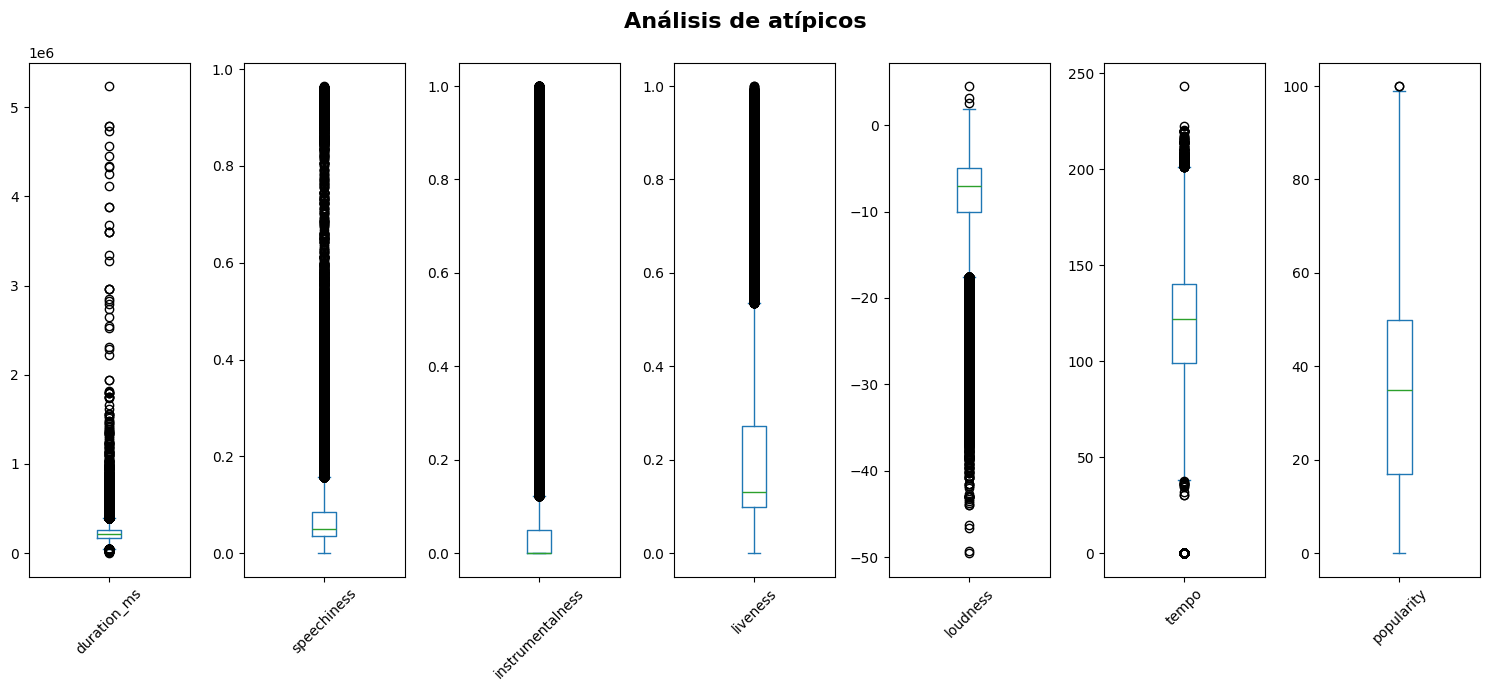

In [15]:
revision_atipicos = ['duration_ms', 'speechiness', 'instrumentalness',	'liveness', 'loudness', 'tempo', 'popularity']
fig, axes = plt.subplots(1, 7 , figsize=(20,20))
axes = axes.flatten()
for i, col in enumerate(revision_atipicos):
  data[col].plot(kind='box',figsize=(15,7), ax=axes[i])
  axes[i].tick_params(axis="x", labelrotation=45)

plt.suptitle("Análisis de atípicos", fontsize=16, fontweight="bold")
plt.tight_layout()

plt.show()

**duration_ms (Duración en ms):**
Evidencia una distribución con asimetría positiva severa. Refleja la coexistencia de pistas estándar con audiolibros, podcasts o grabaciones continuas, además de posibles registros con duración 0 ms en la base.

**speechiness, instrumentalness y liveness (Variables con lineas negras de atípicos):** No se trata de fallos de medición, sino del reflejo de que el catálogo comercial típico está compuesto por música cantada de estudio. Las canciones instrumentales puras (>0.2), pistas habladas/rap denso (>0.2) o conciertos en vivo (>0.5) son una minoría natural, pero matemáticamente el criterio IQR los marca masivamente como outliers.

**loudness (Sonoridad en dB):** Pistas extremadamente silenciosas (efectos de sonido, pistas ambientales o silencios al inicio de grabaciones) jalan la cola izquierda. Los atípicos superiores indican posible compresión agresiva de rango dinámico.

**tempo (BPM):Comportamiento:** Los atípicos son puntuales: valores cercanos a 0 BPM (errores de detección de ritmo o silencios) y pistas muy aceleradas ($>200$ BPM, como géneros electrónicos intensos tipo Drum & Bass o Speedcore).

**popularity (Popularidad):** Prácticamente carece de outliers, salvo un par de puntos aislados en el valor máximo (100). Indica que el catálogo cubre todo el espectro de reproducciones de forma continua.

In [16]:
print(f"Registros con duration_ms = 0: {(data['duration_ms']==0).sum()}")
print(f"Popularidad de ese registro: {data[data['duration_ms']==0]['popularity'].values}")

print(f"\nRegistros con duración mayor a 15 minutos: {(data['duration_ms'] > 900000).sum()}")
data.nlargest(10, 'duration_ms')[['track_name', 'artists', 'duration_ms']]

Registros con duration_ms = 0: 1
Popularidad de ese registro: [0]

Registros con duración mayor a 15 minutos: 153


,track_name,artists,duration_ms
73617,Unity (Voyage Mix) Pt. 1,Tale Of Us,5237295
10935,Crossing Wires 002 - Continuous DJ Mix,Timo Maas,4789026
10984,Crossing Wires 002 - Continuous DJ Mix,Timo Maas,4789026
24348,The Lab 03 - Continuous DJ Mix Part 1,Seth Troxler,4730302
73840,Amnesia Ibiza Underground 10 DJ Mix,Loco Dice,4563897
13344,House of Om - Mark Farina - Continuous Mix,Mark Farina,4447520
13245,Live In Tokyo - Continuous Mix,Mark Farina,4339826
13195,Greenhouse Construction,Mark Farina,4334721
27926,"NQ State of Mind, Vol. 1 - Continuous DJ Mix",Lenzman;Dan Stezo,4246206
101390,Ocean Waves Sounds,Ocean Sounds,4120258


Solo hay 1 canción con duración 0, y resulta que esa misma tiene popularidad 0.Tiene sentido,si el dato de duración está roto, es lógico que tampoco tenga reproducciones ni popularidad registrada.
Por otro lado, hay 153 canciones que superan los 15 minutos. Pero al mirar los nombres, no son canciones normales,son mezclas continuas de DJ ("Continuous DJ Mix"), sets en vivo o sonidos ambientales como "Ocean Waves Sounds". No es un error de los datos, es que el dataset mezcla distintos tipos de contenido bajo la misma categoría de "canción".

In [17]:
print("Registros con tempo = 0:", (data['tempo']==0).sum())
print(f"Porcentaje del dataset: {(data['tempo']==0).mean()*100:.3f}%")
print()
print("Distribución por género de esos registros:")
print(data[data['tempo']==0]['track_genre'].value_counts().head(5))

Registros con tempo = 0: 157
Porcentaje del dataset: 0.138%

Distribución por género de esos registros:
track_genre
sleep          138
iranian          4
guitar           4
ambient          3
world-music      3
Name: count, dtype: int64


Se confirma que existen 157 registros con tempo = 0, y que el 88% de ellos corresponde al género sleep. Esto respalda con evidencia la decisión de mantenerlos,no es un patrón aleatorio de error, sino una concentración real en un género de música ambiental, donde la ausencia de un tempo detectable por el algoritmo de Spotify es un rasgo esperado del contenido, no un fallo de carga.

### *2.6 Identificación de Datos Faltantes y Negativos*

#### *2.6.1 Conteo de nulos en variables cuantitativas*

In [18]:
#Calculamos los nulos en las columnas
nulos = data.select_dtypes(include=['float64', 'int64']).isnull().sum()

#Construimos el DataFrame directamente
df_nulos_cuant = pd.DataFrame({
    'Cantidad_Nulos': nulos,
    'Porcentaje_Nulos': round(nulos / len(data) * 100, 2)
})
#Filtramos las columnas con nulos, ordenamos y desplegamos
resultado = df_nulos_cuant[df_nulos_cuant['Cantidad_Nulos'] > 0].sort_values(by='Porcentaje_Nulos', ascending=False)

if resultado.empty:
    print("No se detectaron valores nulos en ninguna columna numérica del dataset.")
else:
    display(resultado)

No se detectaron valores nulos en ninguna columna numérica del dataset.


#### *2.6.2 Conteo de negativos en variables cuantitativas*

In [19]:
# 1. Calculamos los valores negativos (< 0) en las columnas numéricas
negativos = data.select_dtypes(include=['float64']).lt(0).sum()

# 2. Construimos el DataFrame directamente
df_negativos_cuant = pd.DataFrame({
    'Cantidad_Negativos': negativos,
    'Porcentaje_Negativos': round(negativos / len(data) * 100, 2)
})

# 3. Filtramos las columnas que tengan negativos, ordenamos y desplegamos
display(df_negativos_cuant[df_negativos_cuant['Cantidad_Negativos'] > 0].sort_values(by='Cantidad_Negativos', ascending=False))

,Cantidad_Negativos,Porcentaje_Negativos
loudness,113910,99.92


El 99.92% de los registros presenta valores negativos en la variable loudness. Este comportamiento es coherente con la escala de medida estándar en audio digital (dBFS), donde dB representa la amplitud máxima posible y los valores negativos expresan el nivel de sonoridad promedio de la pista.

### *2.7 Perfilamiento y Consistencia de Atributos Cualitativos*

#### *2.7.1 Análisis Descriptivo de Campos Categorizados*

In [20]:
# Nos muestra todas las variables que son tipo object, nos ayudara a indentificar las variables cualitativas
data.drop(columns=['track_id']).describe(include="object")

,artists,album_name,track_name,track_genre
count,113999,113999,113999,114000
unique,31437,46589,73608,114
top,The Beatles,Alternative Christmas 2022,Run Rudolph Run,acoustic
freq,279,195,151,1000


#### *2.7.2 Conteo de nulos en variables cualitativas*

In [21]:
# 1. Calculamos los nulos en las columnas
nulos = data.select_dtypes(include=['object']).isnull().sum()

# 2. Construimos el DataFrame directamente
df_nulos_cuant = pd.DataFrame({
    'Cantidad_Nulos': nulos,
    'Porcentaje_Nulos': round(nulos / len(data) * 100, 2)
})

# 3. Filtramos las columnas con nulos, ordenamos y desplegamos
display(df_nulos_cuant[df_nulos_cuant['Cantidad_Nulos'] > 0].sort_values(by='Porcentaje_Nulos', ascending=False))

,Cantidad_Nulos,Porcentaje_Nulos
artists,1,0.0
album_name,1,0.0
track_name,1,0.0


#### *2.7.3 Exploración de Dominios y Cardinalidad Categórica*

In [22]:
# Seleccionamos automáticamente las columnas de tipo 'object' (categóricas).
variables_cualitativas = data.drop(columns=['track_id', 'track_name', 'artists', 'album_name']).select_dtypes(include=['object']).columns

# Iteramos para inspeccionar la integridad y los valores posibles de cada atributo.
for col in variables_cualitativas:
    print("_" * 110) # Separador
    print(f"\n Valores de {col}: {data[col].unique()}")
print("_" * 110) # Separador

______________________________________________________________________________________________________________

 Valores de track_genre: ['acoustic' 'afrobeat' 'alt-rock' 'alternative' 'ambient' 'anime'
 'black-metal' 'bluegrass' 'blues' 'brazil' 'breakbeat' 'british'
 'cantopop' 'chicago-house' 'children' 'chill' 'classical' 'club' 'comedy'
 'country' 'dance' 'dancehall' 'death-metal' 'deep-house' 'detroit-techno'
 'disco' 'disney' 'drum-and-bass' 'dub' 'dubstep' 'edm' 'electro'
 'electronic' 'emo' 'folk' 'forro' 'french' 'funk' 'garage' 'german'
 'gospel' 'goth' 'grindcore' 'groove' 'grunge' 'guitar' 'happy'
 'hard-rock' 'hardcore' 'hardstyle' 'heavy-metal' 'hip-hop' 'honky-tonk'
 'house' 'idm' 'indian' 'indie-pop' 'indie' 'industrial' 'iranian'
 'j-dance' 'j-idol' 'j-pop' 'j-rock' 'jazz' 'k-pop' 'kids' 'latin'
 'latino' 'malay' 'mandopop' 'metal' 'metalcore' 'minimal-techno' 'mpb'
 'new-age' 'opera' 'pagode' 'party' 'piano' 'pop-film' 'pop' 'power-pop'
 'progressive-house' 'psych-ro

### *2.8 Análisis de Distribución y Sesgo de la Variable Objetivo*

Se analiza la distribución de la variable objetivo popularity, evaluando su forma, tendencia central y grado de asimetría, con el fin de comprender su comportamiento.

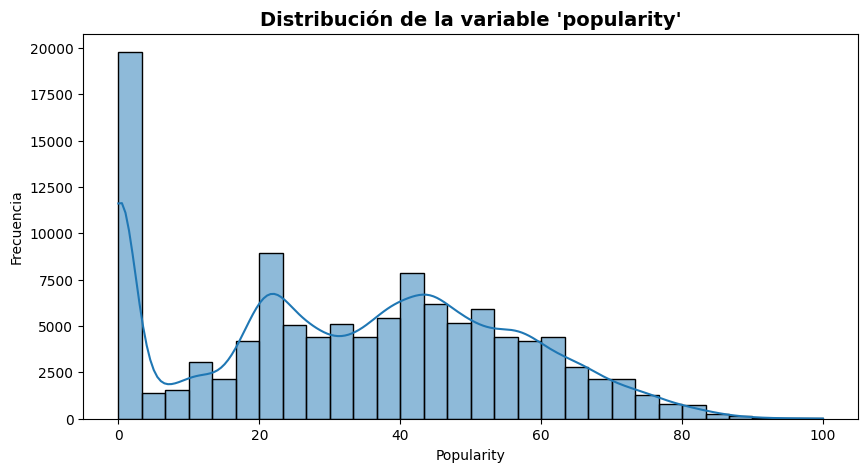

Sesgo de popularity: 0.046
Curtosis: -0.93
Canciones con popularidad 0: 16020, esto equivale a aproximadamente el 14.05% del dataset


In [23]:
plt.figure(figsize=(10, 5))
sns.histplot(data['popularity'], kde=True, bins=30)
plt.title("Distribución de la variable 'popularity'", fontsize=14, fontweight="bold")
plt.xlabel("Popularity")
plt.ylabel("Frecuencia")
plt.show()
print(f"Sesgo de popularity: {skew(data['popularity']):.3f}")
print(f"Curtosis: {data['popularity'].kurt():.2f}")
print(f"Canciones con popularidad 0: {(data['popularity'] == 0).sum()}, esto equivale a aproximadamente el {((data['popularity'] == 0).sum()/len(data)) * 100:.2f}% del dataset")

Lo primero que llama la atención es la barra en 0,casi 20.000 canciones tienen popularidad 0, muy por encima de cualquier otro valor. Después de ese pico hay una caída fuerte y recién desde el rango 15-20 en adelante la distribución empieza a tomar una forma más "normal", con la mayor concentración entre 20 y 55, y bajando de a poco hacia los valores altos (80-100).

Ese grupo de canciones con popularidad 0 probablemente corresponde a temas con muy pocas reproducciones o sin suficiente historial para que Spotify les asigne un puntaje mayor.
Lo siguiente es que el skewness dio casi 0 (0.046),lo que normalmente indicaría una distribución simétrica. Pero el gráfico muestra algo distinto, hay un salto grande en 0 que no se ve reflejado en ese número, porque el resto de la distribución compensa el cálculo. Esto muestra que fijarse solo en el valor de skewness puede llevar a una conclusión equivocada si no se revisa también el histograma.

### *2.9 Distribución de las Variables Numéricas*

Se analiza la distribución individual de las principales variables numéricas del dataset, con el fin de identificar su forma, posibles sesgos y rangos de concentración, complementando el análisis de outliers realizado previamente.

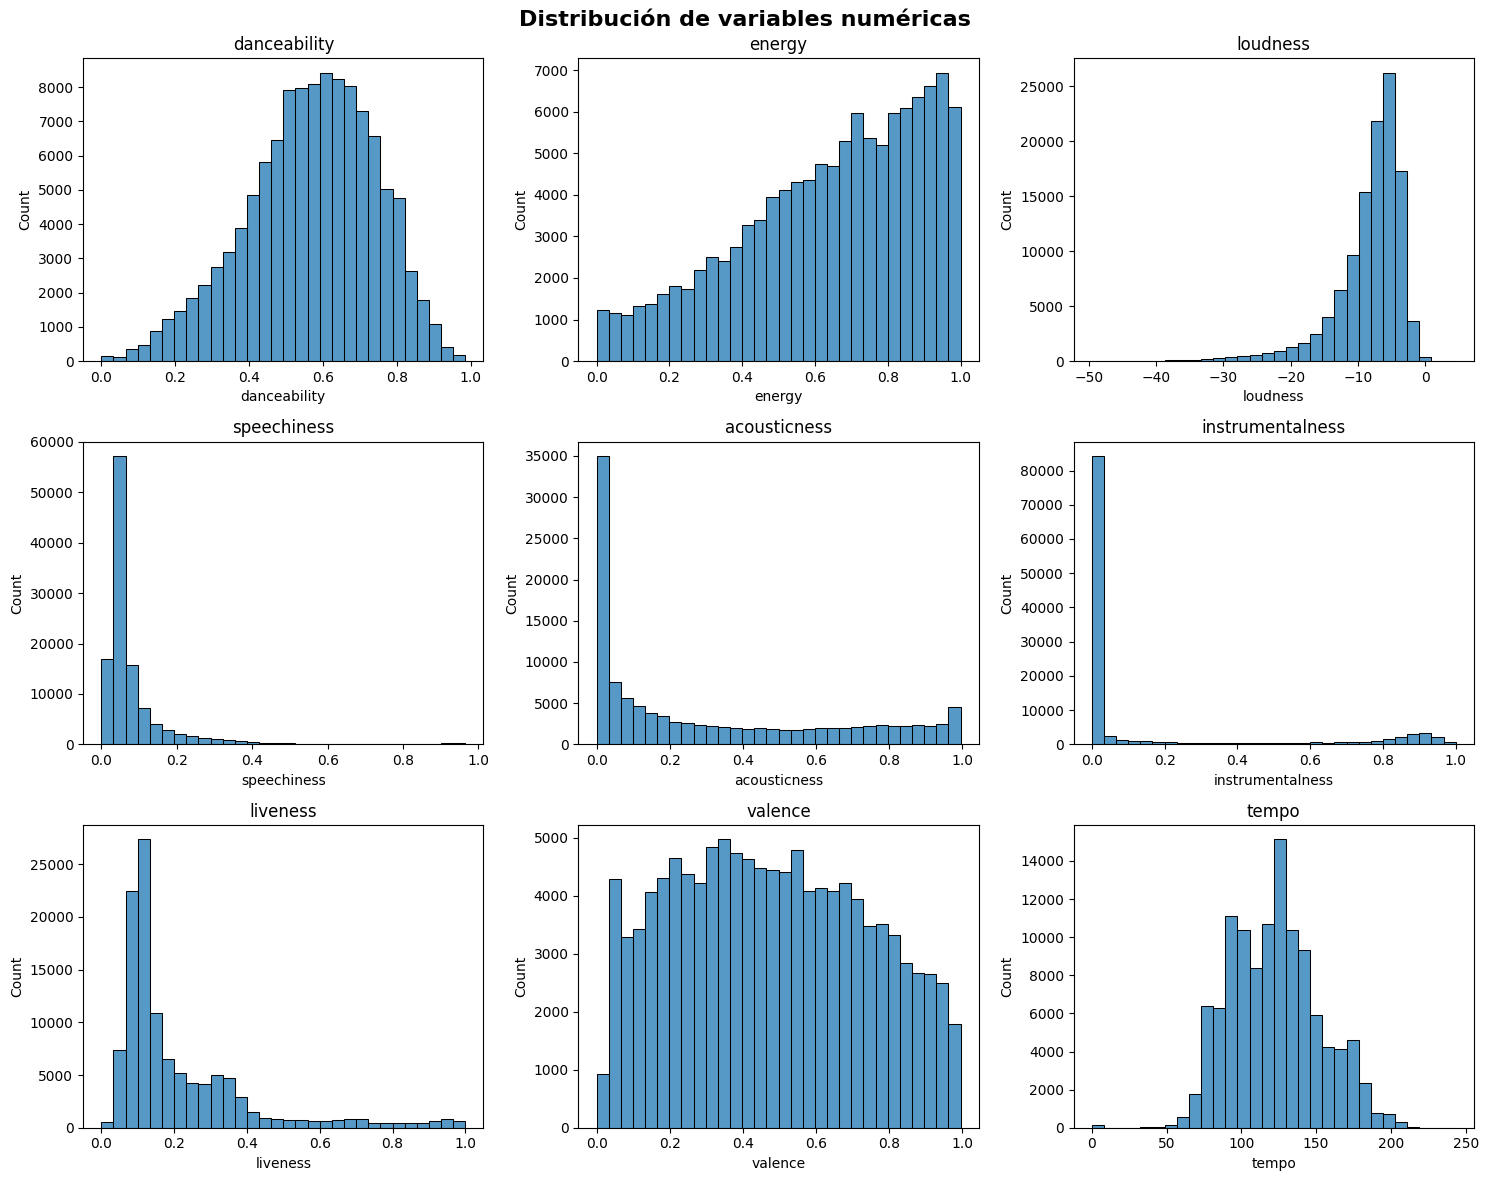

In [24]:
variables_features = ['danceability', 'energy', 'loudness', 'speechiness',
                       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(variables_features):
    sns.histplot(data[col], bins=30, ax=axes[i])
    axes[i].set_title(col)

plt.suptitle("Distribución de variables numéricas", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

Varias de las variables de audio muestran distribuciones muy concentradas en valores bajos (speechiness, instrumentalness, liveness, acousticness),lo que significa que estas columnas aportan poca variabilidad para diferenciar canciones entre sí.

**loudness** está concentrada entre -10 y 0 dB, lo que confirma una práctica común de masterización moderna.La cola hacia valores muy negativos probablemente corresponde a grabaciones más antiguas o de menor calidad de producción, lo que podría ser un factor indirecto relacionado con la popularidad.

**danceability**,**valence** y **tempo** son las variables con distribución más "normal" y balanceada del grupo.

El caso de **acousticness** es particular,además de la concentración en 0, tiene un repunte visible cerca de 1.0. Esto sugiere que el data mezcla dos grupos bastante distintos de canciones, más que una transición gradual entre ambos extremos.

En conjunto, el hallazgo más útil de este análisis es que varias variables (speechiness, instrumentalness, liveness) están dominadas por un solo valor y podrían no ser buenos predictores individuales de popularidad, mientras que variables como loudness, danceability y valence, al tener mayor variabilidad, son candidatas más prometedoras para explorar su relación con **popularity**.

### *2.10 Análisis de Correlación y Multicolinealidad*
Se analiza la relación entre las variables numéricas mediante una matriz de correlación, con el fin de identificar qué variables se asocian más con popularity,y detectar posibles relaciones fuertes entre variables.

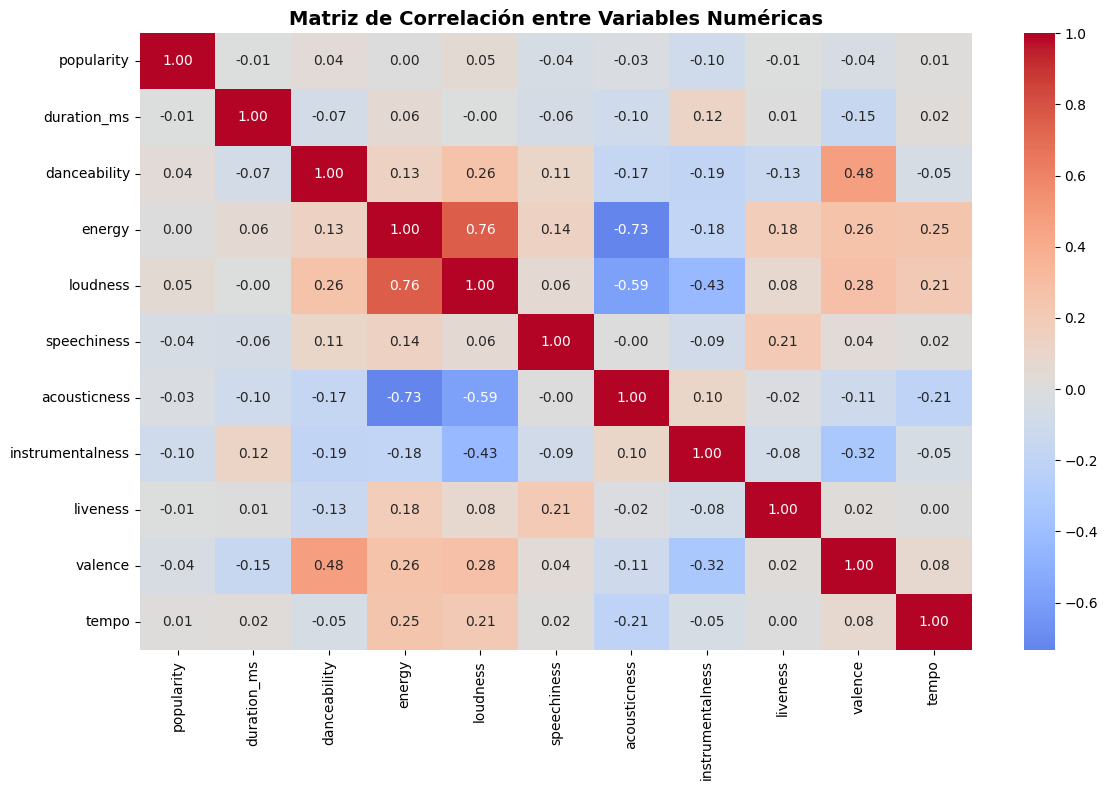

In [25]:
variables_numericas = ['popularity', 'duration_ms', 'danceability', 'energy', 'loudness',
                        'speechiness', 'acousticness', 'instrumentalness', 'liveness',
                        'valence', 'tempo']

matriz_corr = data[variables_numericas].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de Correlación entre Variables Numéricas", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

El hallazgo más importante de esta matriz es que ninguna variable de audio tiene una correlación lineal relevante con popularity,todos los valores están entre -0.10 y 0.05, prácticamente cero. Esto significa que no existe una única característica de audio. que por sí sola explique por qué una canción es más o menos popular.La variable más cercana es instrumentalness, sugiriendo apenas una leve tendencia de que canciones instrumentales tienden a ser un poco menos populares, pero es una relación muy débil para sacar conclusiones.

Esto es relevante para el proyecto, porque la popularidad probablemente no se explica por atributos de audio de forma aislada, sino por una combinación de varios factores a la vez. Un modelo lineal simple basado en estas variables probablemente tendría un poder predictivo limitado.

### *2.11 Análisis de Correlación de Spearman*

La matriz de correlación de Pearson solo captura relaciones **lineales** entre variables. Para verificar si existen relaciones **no lineales** que no fueron detectadas anteriormente,especialmente con la variable objetivo popularity,se calcula adicionalmente la correlación de Spearman, la cual evalúa la relación entre los rangos de las variables en lugar de sus valores absolutos.

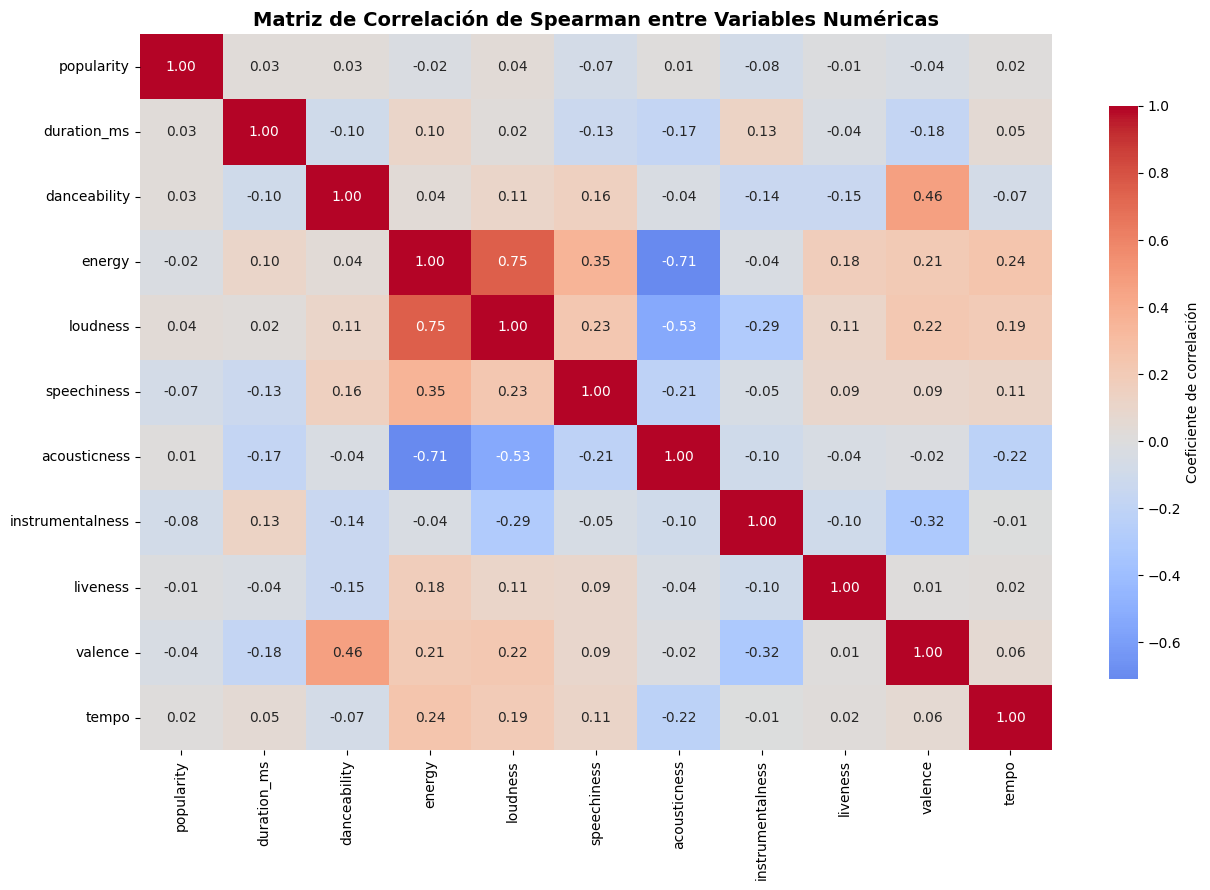

In [26]:
matriz_spearman = data[variables_numericas].corr(method='spearman')

plt.figure(figsize=(13, 9))
sns.heatmap(matriz_spearman, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de correlación'})
plt.title("Matriz de Correlación de Spearman entre Variables Numéricas", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

La matriz de Spearman confirma lo observado con Pearson,tampoco existe una relación relevante entre popularity y las variables de audio. Los valores se mantienen igual de bajos entre -0.08 y 0.04, por lo que descartar relaciones lineales no estaba ocultando una relación no lineal más fuerte — simplemente no hay una asociación fuerte de ningún tipo entre estas variables individuales y la popularidad.


### *2.12 Análisis de Correlación de Atributos Numéricos con la Popularidad*

Identificar qué variables numéricas tienen un impacto con el éxito de una canción en Spotify, y detectar qué atributos no muestran una relación lineal directa con la popularidad (valores cercanos a cero). Esto orienta la selección de características (feature selection) para la etapa de modelado predictivo.

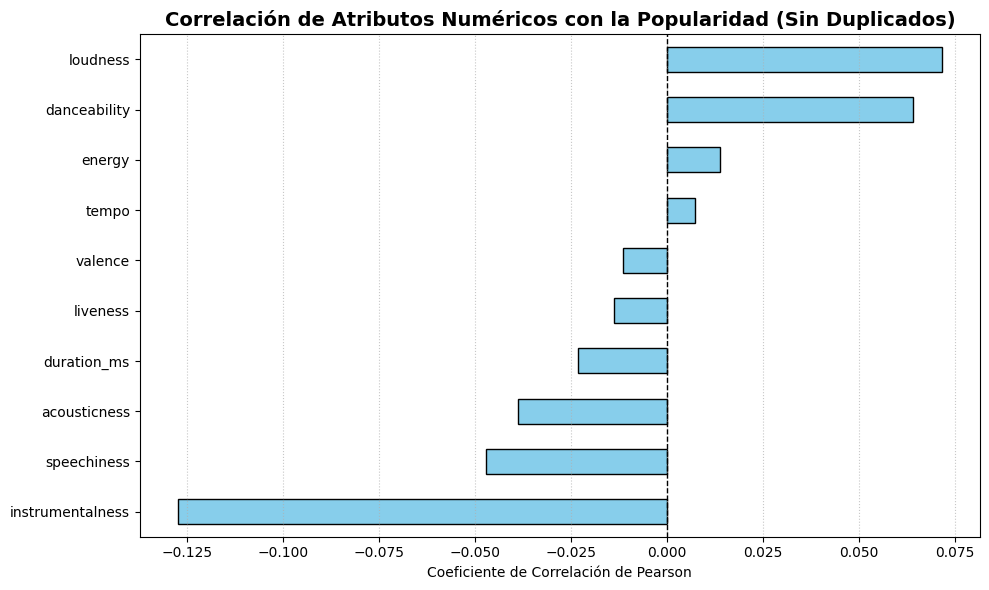

In [27]:
# 1. Asegurar la selección sin alterar listas globales
cols_corr = [col for col in variables_numericas if col != 'popularity'] + ['popularity']

# 2. Matriz sobre el conjunto sin duplicados
corr_series = (
    data.drop_duplicates(subset=['track_id'])[cols_corr]
    .corr(method='pearson')['popularity']
    .drop('popularity')
    .sort_values(ascending=True)
)

# 3. Gráfico
plt.figure(figsize=(10, 6))
corr_series.plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Correlación de Atributos Numéricos con la Popularidad (Sin Duplicados)', fontsize=14, fontweight="bold")
plt.xlabel('Coeficiente de Correlación de Pearson')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

### *2.13 Relación entre popularity y Variables Categóricas*

Dado que las matrices de correlación de Pearson y Spearman no evidenciaron relaciones relevantes entre popularity y las variables de audio, se explora la relación de la variable objetivo con variables categóricas del dataset,el género musical **track_genre** y el carácter explícito de la canción **explicit**, con el fin de identificar si estos factores están más asociados al nivel de popularidad.

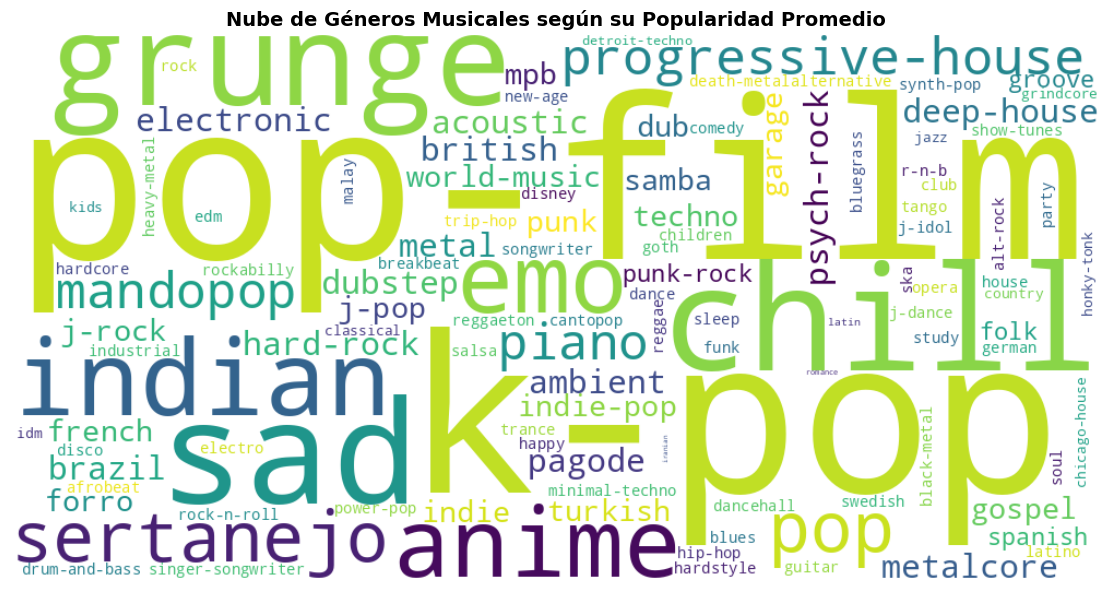

In [28]:
# 1. Calculamos la popularidad promedio por género 
popularidad_genero = data.groupby('track_genre')['popularity'].mean()

# 2. Convertimos la serie de Pandas a un diccionario {género: popularidad_promedio}
frecuencias_genero = popularidad_genero.to_dict()

# 3. Generamos la nube de palabras asignando el tamaño según la popularidad
wordcloud = WordCloud(
    width=1000, 
    height=500, 
    background_color='white', 
    colormap='viridis' # Esquema de colores 
).generate_from_frequencies(frecuencias_genero)

# 4. Graficamos la nube
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # Ocultamos los ejes X e Y
plt.title("Nube de Géneros Musicales según su Popularidad Promedio", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

/root/venv/lib/python3.13/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/root/venv/lib/python3.13/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/root/venv/lib/python3.13/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/root/venv/lib/python3.13/site-packages/seaborn/_base.py:949: FutureWarning: When 

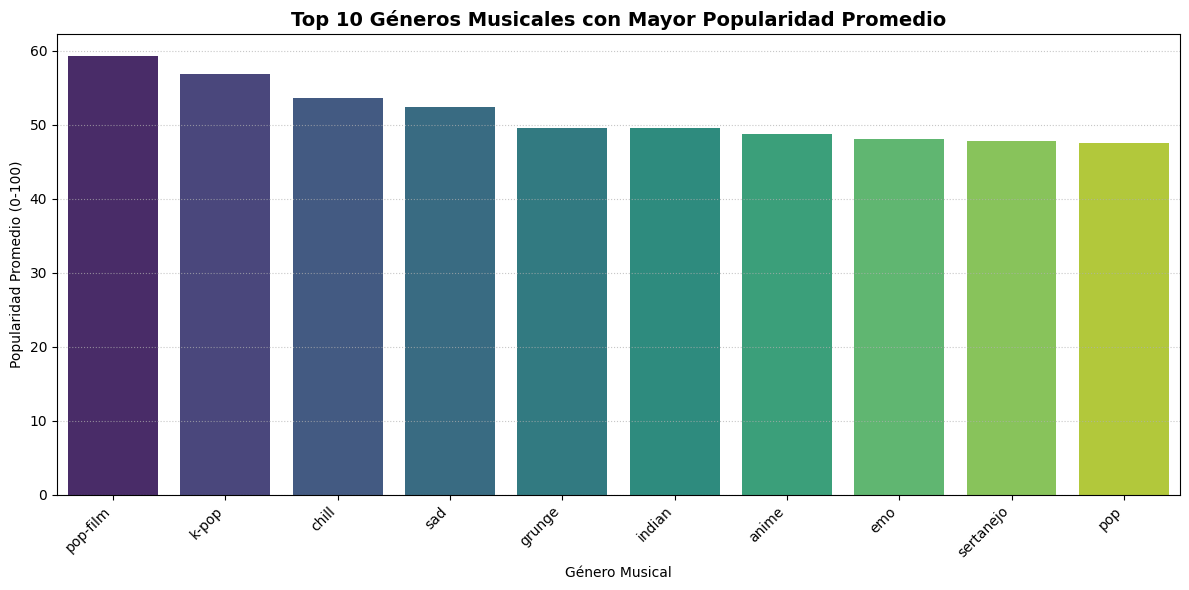

In [29]:
# 1. Agrupar por género, calcular la popularidad promedio y ordenar de mayor a menor
top10_generos = data.groupby('track_genre')['popularity'].mean().reset_index()
top10_generos = top10_generos.sort_values('popularity', ascending=False).head(10)

# 2. Visualizar los 10 géneros más populares
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top10_generos, 
    x='track_genre', 
    y='popularity', 
    hue='track_genre', 
    palette='viridis', 
    legend=False
)

plt.title('Top 10 Géneros Musicales con Mayor Popularidad Promedio', fontsize=14, fontweight="bold")
plt.xlabel('Género Musical')
plt.ylabel('Popularidad Promedio (0-100)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()


A diferencia de las variables de audio, el género musical sí muestra una relación clara con la popularidad. El género más popular en promedio es pop-film (59.3), seguido de k-pop (56.9), chill (53.7),sad (52.4) y grunge (49.6), géneros asociados a la música mainstream y a bandas sonoras de gran exposición mediática. En el otro extremo, géneros como iranian (2.2), romance (3.2) y latin`(8.3) presentan una popularidad promedio muy baja, lo que sugiere que corresponden a nichos con menor alcance dentro de la plataforma o menor representación en el dataset.


**Relación entre popularity y explicit**

In [30]:
data.groupby('explicit')['popularity'].mean()

explicit
False    32.937891
True     36.454191
Name: popularity, dtype: float64

Las canciones marcadas como explícitas tienen en promedio más popularidad (36.45) que las no explícitas (32.94). La diferencia es de casi 3.5 puntos, no es enorme pero es consistente. Puede relacionarse con géneros como el rap o el hip-hop, que suelen combinar contenido explícito con alto consumo en streaming.

### *2.14 Revisión Complementaria: Variables Musicales No Incluidas en la Correlación (key,mode,time_signature)*

Estas tres variables no se incluyeron en las matrices de correlación de las secciones 2.10 y 2.11 porque, si bien están codificadas como números, representan categorías musicales (tonalidad, modo, compás) y no magnitudes continuas.interpretarlas con un coeficiente de correlación de Pearson o Spearman no sería correcto. Por eso se revisan aquí de forma independiente, evaluando su distribución y calidad de datos.

In [31]:
print("Distribución de KEY (tonalidad, 0-11):")
print(data['key'].value_counts().sort_index())

print("\nDistribución de MODE (0=menor, 1=mayor):")
print(data['mode'].value_counts())

print("\nDistribución de TIME_SIGNATURE:")
print(data['time_signature'].value_counts().sort_index())

print("\nRegistros con time_signature = 0 (posible error):")
print(data[data['time_signature'] == 0].shape[0])

print("\nPopularidad promedio por modo:")
print(data.groupby('mode')['popularity'].mean())

Distribución de KEY (tonalidad, 0-11):
key
0     13061
1     10772
2     11644
3      3570
4      9008
5      9368
6      7921
7     13245
8      7360
9     11313
10     7456
11     9282
Name: count, dtype: int64

Distribución de MODE (0=menor, 1=mayor):
mode
1    72681
0    41319
Name: count, dtype: int64

Distribución de TIME_SIGNATURE:
time_signature
0       163
1       973
3      9195
4    101843
5      1826
Name: count, dtype: int64

Registros con time_signature = 0 (posible error):
163

Popularidad promedio por modo:
mode
0    33.650645
1    33.004251
Name: popularity, dtype: float64


key y mode no presentan valores fuera de rango, ya que los 12 tonos (0-11) están representados y mode solo contiene 0 y 1, como corresponde. El 64% de las canciones están en modo mayor (72.681) frente a un 36% en modo menor (41.319), y la popularidad promedio es muy similar entre ambos modos, por lo que el modo musical no parece ser un factor determinante de la popularidad.
En cambio, time_signature sí revela un problema de calidad,163 registros tienen time_signature = 0, un valor inválido ya que un compás musical no puede tener cero tiempos. Este hallazgo es consistente con los registros corruptos de duration_ms = 0.

A diferencia del género musical, estas tres variables no muestran un patrón claro de asociación con la popularidad, por lo que su relevancia para el proyecto es secundaria,aportan principalmente al diagnóstico de calidad de datos.

### *2.15 Resumen de Calidad de Datos*

Se consolidan en un solo indicador porcentual los hallazgos de calidad detectados a lo largo del EDA, evaluando tres dimensiones estándar de calidad de datos, completitud, unicidad y validez.

In [32]:
total_filas = len(data)

# Completitud: filas sin ningún valor nulo
filas_con_nulos = data[['artists', 'album_name', 'track_name']].isnull().any(axis=1).sum()
completitud = (total_filas - filas_con_nulos) / total_filas * 100

# Unicidad: canciones únicas (track_id) sobre el total de filas
unicidad = data['track_id'].nunique() / total_filas * 100

# Validez: filas sin errores conocidos (duration_ms=0 o time_signature=0)
filas_invalidas = data[(data['duration_ms'] == 0) | (data['time_signature'] == 0)].shape[0]
validez = (total_filas - filas_invalidas) / total_filas * 100

promedio_general = (completitud + unicidad + validez) / 3

resumen_calidad = pd.DataFrame({
    'Dimensión': ['Completitud', 'Unicidad', 'Validez'],
    'Cumplimiento (%)': [round(completitud, 2), round(unicidad, 2), round(validez, 2)]
})

display(resumen_calidad)
print(f"\nCalidad general del dataset: {promedio_general:.2f}%")

,Dimensión,Cumplimiento (%)
0,Completitud,100.00
1,Unicidad,78.72
2,Validez,99.86



Calidad general del dataset: 92.86%


El dataset presenta una calidad general del **92,86%**, considerando tres dimensiones:

- **Completitud (100%):** prácticamente no hay registros con campos vacíos; solo 1 fila de 114.000 presenta nulos.
- **Unicidad (78,72%):** esta es la dimensión con mayor falla. Solo el 78,72% de las filas corresponden a canciones distintas; el 21,28% restante son repeticiones de la misma canción bajo distintos géneros (track_id duplicado), confirmado empíricamente en la sección 2.4.1.
- **Validez (99,86%):** casi todos los registros tienen valores dentro de rangos plausibles; solo 164 filas (0,14%) presentan valores inválidos (duration_ms = 0 o time_signature = 0).

### *2.16 Conclusión Final (Toma de Decisiones)*


1. Limpieza Estructural y Prevención de Sesgos

    Columnas residuales y nulos: Eliminar la columna Unnamed: 0 (artefacto de exportación) y aplicar dropna para descartar la única fila con valores faltantes.

    Duplicados exactos y funcionales: Se conserva exclusivamente la primera aparición de cada identificador único (track_id).

    Justificación: Evita la fuga de datos (data leakage) cruzando pistas repetidas entre los conjuntos de entrenamiento y prueba. Adicionalmente, se eliminan todas las variables de texto de alta cardinalidad (artists, album_name, track_name) para suprimir el sesgo de fama comercial e historial, forzando al modelo a operar bajo un enfoque meritocrático.

2. Filtrado de Atípicos y Definición del Dominio Musical

    Anomalías a eliminar: Filtrar pistas con duration_ms igual a 0 ms o mayores a 15 minutos (900,000 ms).

    Justificación: Excluye audiolibros, ruido blanco o mezclas continuas de DJ que no cumplen con el formato estructural de una canción, evitando distorsiones en las métricas.

    Nichos a conservar: Mantener intactas las pistas con valores altos en speechiness, instrumentalness, liveness y aquellas con tempo == 0.

    Justificación: Son características legítimas de géneros específicos (rap, música clásica, grabaciones en vivo, música ambiental). Eliminarlos destruiría la representatividad de estos nichos en el dataset.

3. Ingeniería de Características Estática

    Transformación de booleanos: Convertir la etiqueta explicit de formato True/False a numérico binario (1/0).

    Casteo categórico (key, time_signature): Forzar las variables numéricas de tonalidad y compás a tipo texto (str).

    Justificación: Evita que el algoritmo interprete etiquetas armónicas y rítmicas como magnitudes matemáticas progresivas (ej. asumir que el tono 11 es mayor que el tono 0). Se preparan para ser separadas limpiamente por el One-Hot Encoding.

4. Transformación Avanzada y Escalamiento Relativo (ColumnTransformer)

    Escalamiento de colas largas (RobustScaler): Aplicado a duration_ms, loudness y tempo. Utiliza la mediana y el rango intercuartílico para comprimir la distribución sin que los atípicos válidos (pistas muy ruidosas o rápidas) aplasten la escala.

    Normalización Contextual por Género (El Enfoque Meritocrático): Se descartó el uso del escalador global (MinMaxScaler) y la agrupación por macro-géneros. Se implementó un transformador personalizado que utiliza los 114 subgéneros originales (track_genre) para aplicar un Z-Score a las variables acústicas (danceability, energy, etc.) basado exclusivamente en la media y desviación estándar de su propio nicho. Tras el cálculo, la columna de género se elimina de la matriz.

    Justificación: El modelo ya no premia ni penaliza una canción por la popularidad comercial de su género (ej. Pop vs Jazz). Evalúa matemáticamente si la pista es acústicamente excepcional dentro de su propio ecosistema musical. Al eliminar la etiqueta del género en el paso final, se logra una audición a ciegas libre de sesgos de mercado.


## **3. Preparación y Transformación de Datos**
A partir de los problemas de calidad detectados en la etapa anterior,se prepara una versión limpia del dataset, documentando y justificando cada decisión tomada antes de dejarlo listo para una eventual etapa de modelamiento.

### *3.1 Funciones y Transformadores Personalizados*

Definimos las reglas de negocio y limpieza mediante clases que heredan de BaseEstimator y TransformerMixin, permitiendo que cada paso sea tratado como un componente de "caja negra" dentro de nuestra arquitectura.

In [33]:
def limpieza_estatica_spotify(df):
    """
    Limpieza de errores operativos y transformaciones categóricas estáticas.
    """
    data = df.copy()
    
    # 1. Limpieza estructural
    if 'Unnamed: 0' in data.columns:
        data = data.drop(columns=['Unnamed: 0'])
    data = data.dropna()
    data = data.drop_duplicates(subset=['track_id'], keep='first') 
    
    # 2. Filtrado de Atípicos Operativos (Errores de API o pistas no musicales)
    # Una duración de 0 es un error. Más de 15 min (900,000 ms) son ruido.
    # Un compás (time_signature) de 0 tampoco es válido musicalmente.
    data = data[(data['duration_ms'] > 0) & (data['duration_ms'] <= 900000)]
    data = data[data['time_signature'] != 0]
    
    # 3. Casteo de Booleanos a Enteros
    data['explicit'] = data['explicit'].astype(int)
    
    # 4. Casteo a String de Categóricas "disfrazadas" de numéricas
    data['key'] = data['key'].astype(str)
    data['time_signature'] = data['time_signature'].astype(str)
    
    return data

class ContextualGenreScaler(BaseEstimator, TransformerMixin):
    def __init__(self, genre_col, acoustic_cols):
        self.genre_col = genre_col
        self.acoustic_cols = acoustic_cols
        self.group_stats_ = {}
        self.global_stats_ = {}

    def fit(self, X, y=None):
        # Calculamos la media y desviación estándar POR GÉNERO solo con datos de Train
        for genre in X[self.genre_col].unique():
            subset = X[X[self.genre_col] == genre]
            self.group_stats_[genre] = {
                'mean': subset[self.acoustic_cols].mean(),
                'std': subset[self.acoustic_cols].std() + 1e-8 # Evita división por cero
            }
        
        # Estadísticas globales como plan de contingencia por si en Test aparece un género nuevo
        self.global_stats_ = {
            'mean': X[self.acoustic_cols].mean(),
            'std': X[self.acoustic_cols].std() + 1e-8
        }
        return self

    def transform(self, X):
        X_transformed = X.copy()
        
        for genre in X[self.genre_col].unique():
            mask = X[self.genre_col] == genre
            
            if genre in self.group_stats_:
                means = self.group_stats_[genre]['mean']
                stds = self.group_stats_[genre]['std']
            else:
                means = self.global_stats_['mean']
                stds = self.global_stats_['std']
                
            # Normalización Z-Score contextual
            X_transformed.loc[mask, self.acoustic_cols] = (X_transformed.loc[mask, self.acoustic_cols] - means) / stds
            
        # Eliminar la columna de género ya cumplida su función
        return X_transformed.drop(columns=[self.genre_col])

### *3.2 Configuración del Pipeline*
Implementamos un ColumnTransformer para procesar de forma diferenciada las ramas numérica y categórica, consolidando todo en un pipeline final.

In [34]:

def crear_pipeline_spotify():
    # 1. Reestructuración de Variables
    acoustic_cols = ['danceability', 'energy', 'speechiness', 'acousticness', 
                     'instrumentalness', 'liveness', 'valence']
    
    # El género y las métricas acústicas se agrupan para entrar al transformador personalizado
    context_features = ['track_genre'] + acoustic_cols 
    
    skewed_features = ['duration_ms', 'loudness', 'tempo']
    binary_features = ['mode', 'explicit'] # Se MANTIENE intactas (0 y 1)
    cat_features = ['key', 'time_signature'] # Solo quedan tono y compás PASAR POR One-Hot

    # 2. Sub-Pipelines
    contextual_pipeline = Pipeline(steps=[
        ('z_score_contextual', ContextualGenreScaler(genre_col='track_genre', acoustic_cols=acoustic_cols))
    ])

    skewed_pipeline = Pipeline(steps=[
        ('robust_scaler', RobustScaler())
    ])

    categorical_pipeline = Pipeline(steps=[
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    # 3. Ensamble del ColumnTransformer
    preprocessor = ColumnTransformer(
        transformers=[
            ('contextual', contextual_pipeline, context_features),
            ('skewed', skewed_pipeline, skewed_features),
            ('cat', categorical_pipeline, cat_features),
            ('pass', 'passthrough', binary_features) # Pasan directo sin transformación
        ],
        verbose_feature_names_out=False
    )
    
    return preprocessor

### *3.3 Ejecución y Verificación de Resultados*

Aplicamos el flujo completo para obtener un dataset preparado para el análisis estratégico de tendencias.


In [35]:
# 1. Carga y limpieza estática
df_clean = limpieza_estatica_spotify(data) 

# 2. Segregación X e y
y = df_clean['popularity']

# Eliminamos la variable objetivo y TODAS las columnas de texto/ID 
# para asegurar el enfoque meritocrático acústico.
cols_to_drop = ['popularity', 'track_id', 'track_name', 'artists', 'album_name']
X = df_clean.drop(columns=[col for col in cols_to_drop if col in df_clean.columns])

# 3. División (Train-Test Split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Instanciación y entrenamiento
preprocessor = crear_pipeline_spotify()

# Como activamos transform_output="pandas", esto ya nos devuelve DataFrames listos, 
# con sus índices correctos y nombres de columnas. Nos ahorramos todo el código de conversión.
X_train_processed = preprocessor.fit_transform(X_train, y_train)
X_test_processed = preprocessor.transform(X_test)

# 5. Verificación de la estructura lista para modelar
print(f"Dimensiones de entrenamiento: {X_train_processed.shape}")
print(f"Dimensiones de prueba: {X_test_processed.shape}")
display(X_train_processed.head())

Dimensiones de entrenamiento: (71551, 28)
Dimensiones de prueba: (17888, 28)


,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,duration_ms,loudness,tempo,...,key_6,key_7,key_8,key_9,time_signature_1,time_signature_3,time_signature_4,time_signature_5,mode,explicit
809,1.028369,-1.360775,-0.429014,1.159647,-0.235276,1.329969,0.398692,-1.033949,-0.823484,-0.443961,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1,0
93032,0.434583,-0.013880,-0.251945,0.456597,-0.365059,-0.265900,0.269953,-0.200074,-0.651781,-0.374788,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0
16803,1.014037,-0.797800,-0.031544,0.525547,0.844599,-0.484365,1.451012,-1.788839,-3.845043,-0.074628,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,0
4329,0.034014,-0.355233,0.834268,0.731329,0.631651,-0.245641,-0.759174,-1.484005,-2.839846,-0.179064,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1,0
32525,0.563775,-0.439599,-0.364748,-0.535793,-0.727873,-0.538479,-0.169304,-1.166895,0.053705,0.687554,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0


In [36]:
display(X_train_processed.info())

<class 'pandas.core.frame.DataFrame'>
Index: 71551 entries, 809 to 16818
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   danceability      71551 non-null  float64
 1   energy            71551 non-null  float64
 2   speechiness       71551 non-null  float64
 3   acousticness      71551 non-null  float64
 4   instrumentalness  71551 non-null  float64
 5   liveness          71551 non-null  float64
 6   valence           71551 non-null  float64
 7   duration_ms       71551 non-null  float64
 8   loudness          71551 non-null  float64
 9   tempo             71551 non-null  float64
 10  key_0             71551 non-null  float64
 11  key_1             71551 non-null  float64
 12  key_10            71551 non-null  float64
 13  key_11            71551 non-null  float64
 14  key_2             71551 non-null  float64
 15  key_3             71551 non-null  float64
 16  key_4             71551 non-null  float64
 

None

### *3.4 Análisis de Correlación: Radar de Impacto Global*

**Propósito:** Un gráfico de barras horizontales divergentes que muestra el Top 10 de variables que impulsan positivamente la popularidad, y el Top 10 que generan rechazo.

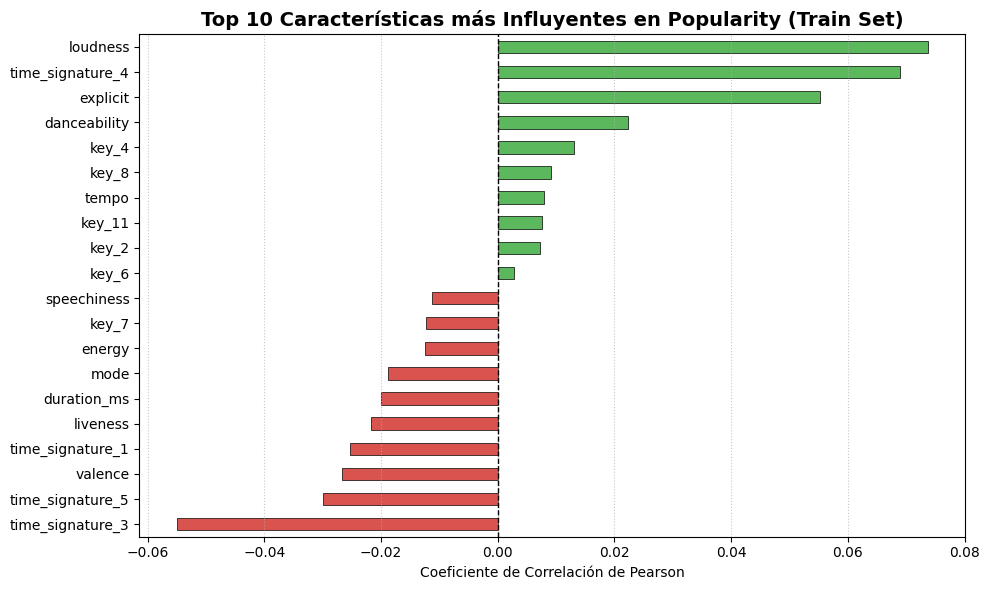

In [37]:
# 1. Unir temporalmente las características procesadas con el target
df_train_corr = X_train_processed.copy()
df_train_corr['popularity'] = y_train.values

# 2. Calcular la correlación de Pearson y aislar 'popularity'
corr_popularity_nueva = (
    df_train_corr.corr(method='pearson')['popularity']
    .drop('popularity')
    .sort_values(ascending=True)
)

# 3. Filtrar el Top 5 más negativo y el Top 5 más positivo
top_10_corr = pd.concat([corr_popularity_nueva.head(10), corr_popularity_nueva.tail(10)])

# 4. Visualización enfocada en el Top 10
plt.figure(figsize=(10, 6)) # Se redujo la altura al ser solo 10 barras
colors = ['#d9534f' if x < 0 else '#5cb85c' for x in top_10_corr.values]

top_10_corr.plot(kind='barh', color=colors, edgecolor='black', linewidth=0.5)

plt.title('Top 10 Características más Influyentes en Popularity (Train Set)', fontsize=14, fontweight='bold')
plt.xlabel('Coeficiente de Correlación de Pearson')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

Hallazgos Claves

    Factores comerciales positivos: El volumen de masterización (loudness) y el compás estándar time_signature_4 (ritmo universal de 4/4) lideran ahora las correlaciones positivas, demostrando que la fuerza sonora y las estructuras rítmicas tradicionales impulsan el éxito de la canción independientemente de su género.

    Destacar en bailabilidad (danceability) en comparación con el promedio de su propio nicho y contener letras explícitas (explicit) mantienen una tendencia consistente al alza, captando la atención del oyente moderno en plataformas de streaming.

    Factores de penalización comercial: Los compases menos accesibles como time_signature_3 (ritmo de vals) y time_signature_5 presentan las correlaciones negativas más fuertes. Esto nos dice que al oyente masivo le cuesta consumir ritmos que rompen el molde estándar.

    Variables de ambiente y formato, como una alta sensación de grabación en vivo (liveness), pistas excesivamente largas (duration_ms) y niveles extremos de positividad (valence), castigan el rendimiento comercial frente a las versiones pulidas de estudio.

    Elementos acústicos puros como acousticness o altas tasas de speechiness (hablar/rap extremadamente hablado) muestran una relación negativa con la popularidad, aunque de magnitud más débil que las anteriores, sugiriendo un efecto menor pero consistente en la misma dirección.


### *3.5 Validación y Conclusiones del Pipeline de Datos*




    1. Limpieza Estructural y Prevención de Sesgos: Se eliminó la columna residual del índice y la única fila nula. Se aplicó un filtro estricto por track_id para conservar una única aparición por canción, previniendo la fuga de datos (data leakage). Además, se eliminaron directamente las variables de texto y metadatos (artists, album_name, track_name) para suprimir cualquier sesgo de fama comercial, y se depuraron anomalías operativas (duración de 0 ms o superior a 15 minutos). 

    2. Ingeniería de Características Estática: Se conservaron los 114 subgéneros musicales originales (track_genre) intactos para usarlos como anclas de contexto. Se casteó la variable explicit a numérica (1/0) y se forzaron las variables de tonalidad (key) y compás (time_signature) a formato de texto, preparándolas para el One-Hot Encoding sin que el algoritmo asuma falsas progresiones matemáticas. 
    
    3. División Estricta de Datos (Train-Test Split): Se separó la matriz predictora de la variable objetivo antes de cualquier transformación estadística dinámica, garantizando que el conjunto de prueba permanezca totalmente aislado y libre de contaminación futura. 

    4. Transformación Avanzada y Normalización Relativa (ColumnTransformer): Se aplicó un tratamiento matemático diferenciado: un RobustScaler a las variables con colas largas (duration_ms, loudness, tempo); One-Hot Encoding a los tonos y compases; y paso directo a los booleanos. Se reemplazó el escalado global por un transformador personalizado que aplica un Z-Score a las métricas acústicas, evaluándolas exclusivamente contra la media y desviación de su propio subgénero. Al finalizar el cálculo, la columna de género se elimina de la matriz, obligando al modelo a realizar una "audición a ciegas" enfocada puramente en el mérito sonoro.


### *3.6 Implementaciónes Futuras (Susceptible de cambio)*


Dado que descubrimos que un 14% de las canciones son un bloque de ceros y que el algoritmo de Spotify asigna puntajes de forma exponencial basándose en la frescura de las reproducciones, decidimos que la variable objetivo no puede atacarse de frente con un regresor tradicional. Por lo tanto la idea es dividir la predicción en un modelo de dos etapas: primero se convierte internamente en una clase binaria para entrenar un modelo que adivine si la canción sera popular o no. Luego, tomando únicamente las canciones que sobrevivieron a ese filtro positivo, se le aplicara una transformación matemática logarítmica para aplanar su curva exponencial y se entrena un regresor que prediga la magnitud real de su éxito.

## **4. Evaluación de Sesgos, Ética y Privacidad de los Datos**
El análisis del impacto ético y la privacidad del catálogo se centra en los sesgos detectados durante la exploración. Se evalúa cómo el hecho de tener exactamente 1.000 temas por género y las diferencias de popularidad entre culturas pueden provocar que un algoritmo discrimine a ciertos artistas, confirmando al mismo tiempo que la información analizada no vulnera la privacidad de los oyentes al tratarse exclusivamente de metadatos de las canciones.

### *4.1 Privacidad y Protección de Datos Personales*
* El dataset no contiene nombres, correos, identificadores de cuenta, direcciones IP ni historiales privados de reproducción de usuarios.
* Todas las variables corresponden a mediciones acústicas calculadas por la API de Spotify sobre las pistas de audio  y a información pública de catálogo.
* No se vulneran normativas de privacidad ni protección de datos personales al no existir perfilamiento sobre individuos.

### *4.2 Sesgo de Muestreo: 1.000 Canciones Fijas por Género*
Se constató que los 114 géneros tienen exactamente 1.000 pistas cada uno.
En las plataformas de streaming el consumo no es parejo.Estilos masivos como el pop o la música urbana concentran millones de reproducciones diarias, mientras que el jazz o el grindcore representan nichos reducidos.Si se dejan 1.000 canciones para cada género no refleja la realidad de Spotify.El modelo aprenderia que todos los géneros son igual de importantes y puede predecir un éxito falso para estilos que tienen muy pocos oyentes.

Frente a este riesgo, se implementó el Enfoque Híbrido Relativo. Al estandarizar los atributos acústicos mediante un Z-score dentro de cada género y descartar posteriormente la columna track_genre, el modelo pierde el acceso directo a la etiqueta comercial. Esto evita que el algoritmo aprenda a favorecer sistemáticamente a los estilos masivos basándose en su volumen de datos. Sin embargo, esta decisión metodológica no corrige el sesgo estructural del mercado de fondo: persiste el riesgo de que la varianza dentro de estilos muy homogéneos se amplifique artificialmente, y el techo comercial de los géneros de nicho no desaparece simplemente porque una obra destaque dentro de su propia categoría.

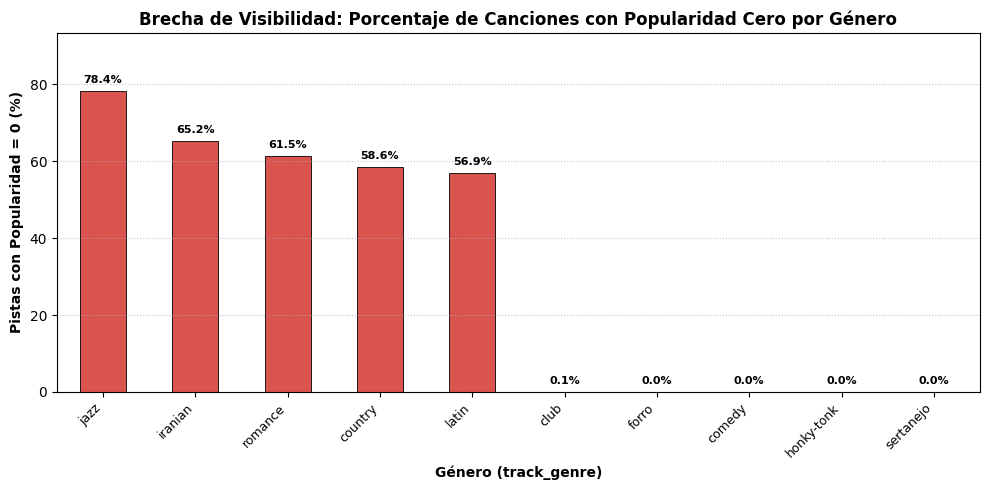

In [39]:
# 1. Calcular el porcentaje de pistas con popularidad 0 por género
porcentaje_ceros = (df_clean['popularity'] == 0).groupby(df_clean['track_genre']).mean() * 100
porcentaje_ceros = porcentaje_ceros.sort_values(ascending=False)

# 2. Tomar los 5 con MAYOR porcentaje de ceros (head) y los 5 con MENOR porcentaje (tail)
comparativa_ceros = pd.concat([porcentaje_ceros.head(5), porcentaje_ceros.tail(5)])

# 3. Configuración del gráfico
plt.figure(figsize=(10, 5))
# 5 rojos para los más penalizados (alta tasa de 0s), 5 azules para los más comerciales
colors_ceros = ['#d9534f'] * 5 + ['#2E77D0'] * 5

ax = comparativa_ceros.plot(kind='bar', color=colors_ceros, edgecolor='black', linewidth=0.6)
plt.title('Brecha de Visibilidad: Porcentaje de Canciones con Popularidad Cero por Género', fontsize=12, fontweight='bold')
plt.xlabel('Género (track_genre)', fontweight='bold')
plt.ylabel('Pistas con Popularidad = 0 (%)', fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.grid(axis='y', linestyle=':', alpha=0.7)

# 4. Agregar etiquetas de porcentaje sobre cada barra
for i, v in enumerate(comparativa_ceros.values):
    ax.text(i, v + 2, f"{v:.1f}%", ha='center', fontsize=8, fontweight='bold')

# Dar un poco de margen superior para que las etiquetas no se corten
plt.ylim(0, max(comparativa_ceros.values) + 15)
plt.tight_layout()
plt.show()

El gráfico muestra que jazz es el caso más extremo,un 78,4% de sus canciones tiene popularidad cero, es decir casi 8 de cada 10 canciones del género nunca tuvieron ningún éxito. Le siguen iranian con 65,2%, romance con 61,5%, country con 58,6% y latin con 56,9%, todos por sobre el 55%. Lo llamativo es que country y latin no son géneros de audiencia reducida, y aun así están casi al mismo nivel que jazz, lo que muestra que la falta de visibilidad comercial no depende solo de qué tan pequeño es el público de un estilo, también afecta a géneros grandes.

Con esto queda demostrado que la cuota fija de 1.000 canciones por género esconde una desigualdad real de éxito comercial entre géneros, y no es solo una sospecha teórica. Esto justifica por qué era necesario aplicar una corrección antes de entrenar el modelo,si un modelo aprendiera directamente de estos datos crudos, asumiría que jazz e iranian merecen tanta popularidad como cualquier otro género, cuando en la práctica la mayoría de sus canciones nunca tuvo tracción real.

/tmp/ipykernel_465/2666976451.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/root/venv/lib/python3.13/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/root/venv/lib/python3.13/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/root/venv/lib/python3.13/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead 

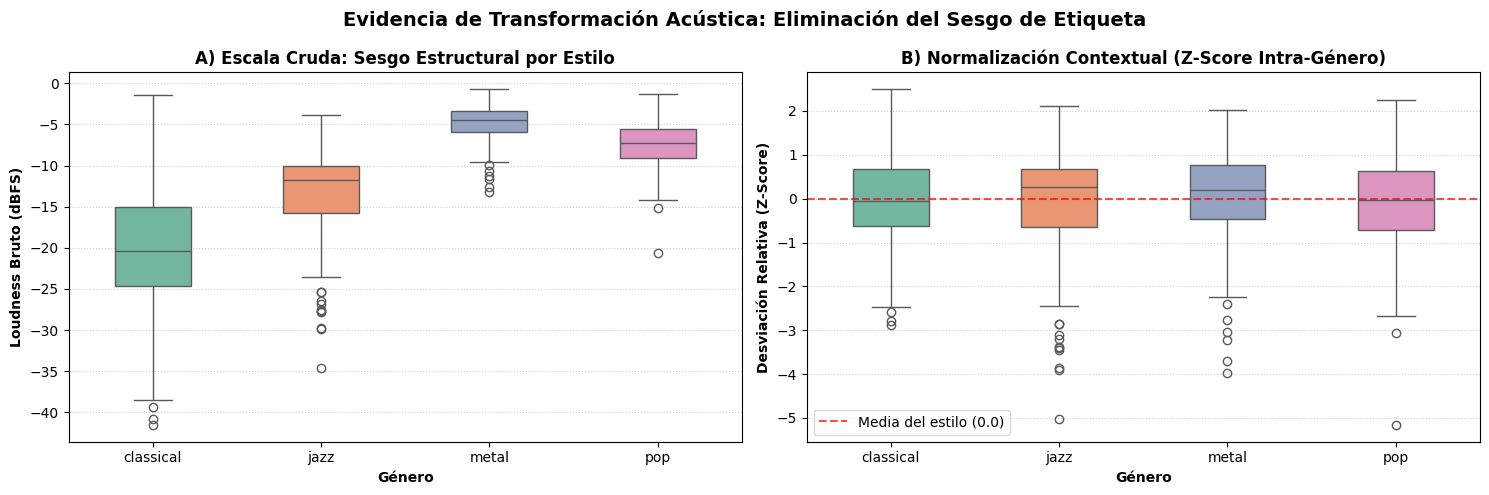

In [40]:
# 1. Seleccionar 4 géneros contrastantes del catálogo
generos_demo = ['classical', 'jazz', 'metal', 'pop']
df_demo = df_clean[df_clean['track_genre'].isin(generos_demo)].copy()

# 2. Calcular el Z-score intra-género para loudness
df_demo['loudness_z_score'] = df_demo.groupby('track_genre')['loudness'].transform(
    lambda x: (x - x.mean()) / (x.std() + 1e-8)
)

# 3. Crear figura comparativa Antes vs Después
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel 1: Escala Absoluta (Sesgo Estructural)
sns.boxplot(
    data=df_demo, x='track_genre', y='loudness', order=generos_demo,
    palette='Set2', ax=axes[0], width=0.45
)
axes[0].set_title('A) Escala Cruda: Sesgo Estructural por Estilo', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Género', fontweight='bold')
axes[0].set_ylabel('Loudness Bruto (dBFS)', fontweight='bold')
axes[0].grid(axis='y', linestyle=':', alpha=0.6)

# Panel 2: Escala Relativa (Normalización Contextual)
sns.boxplot(
    data=df_demo, x='track_genre', y='loudness_z_score', order=generos_demo,
    palette='Set2', ax=axes[1], width=0.45
)
axes[1].axhline(0, color='red', linestyle='--', alpha=0.7, label='Media del estilo (0.0)')
axes[1].set_title('B) Normalización Contextual (Z-Score Intra-Género)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Género', fontweight='bold')
axes[1].set_ylabel('Desviación Relativa (Z-Score)', fontweight='bold')
axes[1].grid(axis='y', linestyle=':', alpha=0.6)
axes[1].legend()

plt.suptitle('Evidencia de Transformación Acústica: Eliminación del Sesgo de Etiqueta', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

A) El Problema del Sesgo Estructural (Panel Izquierdo)
    En la escala cruda de loudness (medida en dBFS), se evidencia la desigualdad inherente de la masterización musical. La música clásica tiene una mediana natural muy baja (cercana a los -20 dBFS) y una gran dispersión (rango dinámico amplio), mientras que géneros como el metal operan en un bloque denso y extremadamente ruidoso (mediana de -5 dBFS).

    Impacto en un modelo tradicional: Si le entregamos estos datos crudos a un algoritmo, este aprenderá a usar el volumen como un "atajo" para adivinar el género (ej. "si es silencioso, es clásica; si es clásica, no es popular"). El modelo castigaría automáticamente a una pista de jazz o clásica simplemente por sonar como debe sonar su estilo.

B) La Solución (Panel Derecho)
    Tras aplicar la normalización Z-Score intra-género, el panorama cambia radicalmente. Las distribuciones de los cuatro géneros ilustrados se han alineado, centrando sus medias exactamente en el eje 0.0. La escala Y ya no mide decibelios brutos, sino desviaciones estándar respecto al promedio de su propio estilo.

    Impacto: Una canción clásica con un valor de +1.5 y una de metal con un valor de +1.5 ahora significan matemáticamente lo mismo para el algoritmo: "Esta pista es excepcionalmente ruidosa en comparación con sus pares directos".

Además del efecto de visibilidad recién mostrado, la cuota fija original de 1.000 canciones por subgénero tampoco garantiza una representación pareja una vez limpio el dataset: al eliminar duplicados por `track_id`, cada género quedó con un número distinto de pistas únicas, y esa asimetría se traslada directamente a las estadísticas por género (media y desviación) que calcula el `ContextualGenreScaler`.

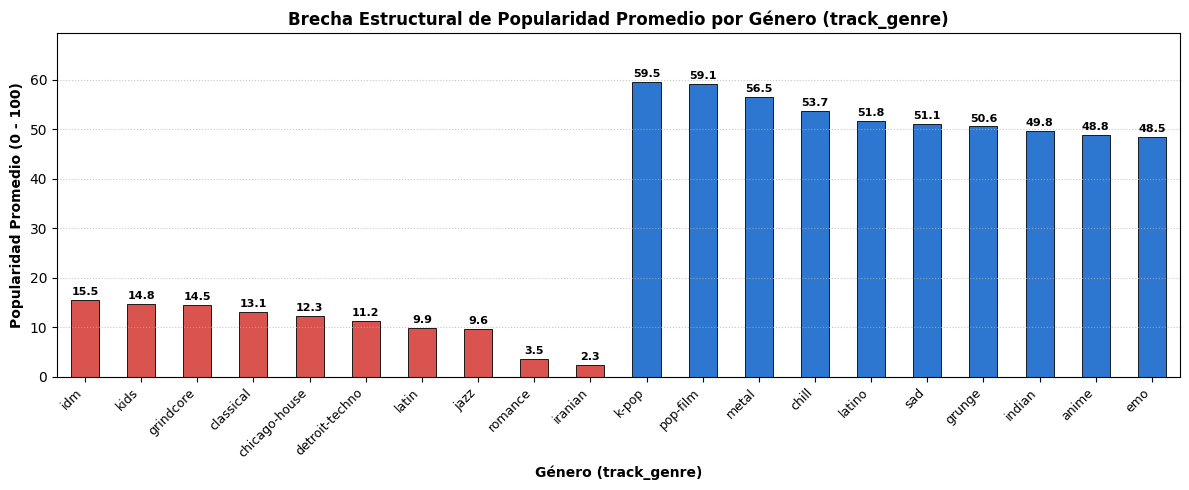

In [41]:
# Disparidad de Popularidad Promedio: Top 10 géneros con menor media vs Top 10 con mayor media
pop_media = df_clean.groupby('track_genre')['popularity'].mean().sort_values(ascending=False)
comparativa_pop = pd.concat([pop_media.tail(10), pop_media.head(10)])

plt.figure(figsize=(12, 5))
colors_pop = ['#d9534f'] * 10 + ['#2E77D0'] * 10

ax = comparativa_pop.plot(kind='bar', color=colors_pop, edgecolor='black', linewidth=0.6)
plt.title('Brecha Estructural de Popularidad Promedio por Género (track_genre)', fontsize=12, fontweight='bold')
plt.xlabel('Género (track_genre)', fontweight='bold')
plt.ylabel('Popularidad Promedio (0 - 100)', fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.grid(axis='y', linestyle=':', alpha=0.7)

for i, v in enumerate(comparativa_pop.values):
    ax.text(i, v + 1, f"{v:.1f}", ha='center', fontsize=8, fontweight='bold')

plt.ylim(0, max(comparativa_pop.values) + 10)
plt.tight_layout()
plt.show()

Tras la deduplicación por track_id, el número de pistas únicas por track_genre pasa a variar entre 73 y 1.000 (promedio ≈793), en lugar de la cuota pareja original de 1.000. A eso se suma una brecha marcada de popularidad promedio entre géneros: k-pop (59,5) y pop-film (59,1) encabezan el ranking, mientras que romance (3,5) e iranian (2,3) lo cierran. Como el ContextualGenreScaler calcula sus estadísticas de referencia usando solo los datos disponibles de cada género en X_train, los géneros con menos pistas únicas que suelen coincidir con los peor posicionados en popularidad quedan con una media y desviación menos robustas. Esto confirma que la estandarización relativiza la escala acústica, pero no corrige el tamaño ni la representatividad real de la muestra por género.

### *4.3 Sesgo de Popularidad por Origen Cultural*
Se observan diferencias muy marcadas de popularidad promedio entre géneros de alcance global y géneros locales o tradicionales.Esta brecha probablemente no refleja una diferencia real de calidad musical, sino desigualdades históricas en la inversión de marketing y distribución entre mercados. Un sistema entrenado sin corrección sobre estos datos tendería a favorecer sistemáticamente a los géneros y artistas ya establecidos comercialmente, dejando en desventaja a creadores independientes o de mercados regionales, lo que constituye una forma de sesgo histórico y cultural.

### *4.4 Responsabilidad Profesional*

Ninguna de las transformaciones aplicadas en este proyecto es una caja negra,el escalamiento y la codificación son técnicas interpretables, cuyo resultado puede rastrearse y explicarse en su totalidad. Esto es relevante porque las decisiones tomadas durante la preparación de los datos tienen consecuencias reales sobre qué música terminaría siendo recomendada o promovida por un eventual sistema basado en este análisis, y esa responsabilidad recae en el equipo que diseñó la solución, no en el algoritmo en sí.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=d9e4801b-3255-44b3-8020-c64ca67fe951' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>